In [5]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from collections import namedtuple

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

###################### Plotting Style ######################
from cycler import cycler

plt.style.use('seaborn-v0_8-colorblind')

# Get current property cycle (the seaborn colorblind palette)
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

# Add an extra color
extra_color = "#6C7394"  
colors.append(extra_color)

# Set the new color cycle
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)

# higher resolution
plt.rcParams['figure.dpi'] = 300

# RESULT_CSV = os.path.join("post_rebuttal_results", "allstar_results_for_plotting_0314.csv")
RESULT_CSV = os.path.join("post_rebuttal_results", "scores_asr.csv")
columns = ['dataset', 'model', 'release_date', 'sample_id', 'native_language', 'groundtruth',  'prediction', 'wer', 'cer']

if os.path.exists(RESULT_CSV):
    results = pd.read_csv(RESULT_CSV)

# if it's the allstar dataset, fuse dataset and task into a new column called "dataset"
# results['dataset'] = results['dataset'] + "_" + results['task']



In [6]:
results['dataset'].unique()

array(['TIMIT', 'EpaDB', 'SpeechOcean', 'ISLE', 'L2-Arctic Spontaneous',
       'BELC', 'Openslr70', 'SAA', 'CORAAL', 'L2-Arctic', 'Openslr83',
       'L1-Arctic'], dtype=object)

In [7]:
dataset_to_img_filename_mapping = {
    'L2-Arctic': 'l2_arctic.png',
    'L2-Arctic Spontaneous': 'l2_arctic_spontaneous.png',
    'Openslr83': 'OpenSLR_83.png', 
    'SAA': 'SAA.jpg',
    'L1-Arctic': 'l1_arctic.png',
    'ALLSTAR_DHR': 'allstar_wer_plot_DHR.png',
    'ALLSTAR_HT1': 'allstar_wer_plot_HT1.png',
    'ALLSTAR_HT2': 'allstar_wer_plot_HT2.png',
    'ALLSTAR_LPP': 'allstar_wer_plot_LPP.png'
}


=== Dataset: L2-Arctic ===
  native_language  avg_regression  max_regression
0          Arabic        0.009342        0.410482
1         Chinese        0.008802        0.306781
2           Hindi        0.006254        0.253570
3          Korean        0.008346        0.407148
4         Spanish        0.008078        0.326264
5             USA        0.011181        0.522672
6      Vietnamese        0.008054        0.232347

Max regression (USA): 52.27%

Native regression (USA): 52.27%

Average max regression (all languages except USA): 32.28%

Average max regression (all languages): 35.13%


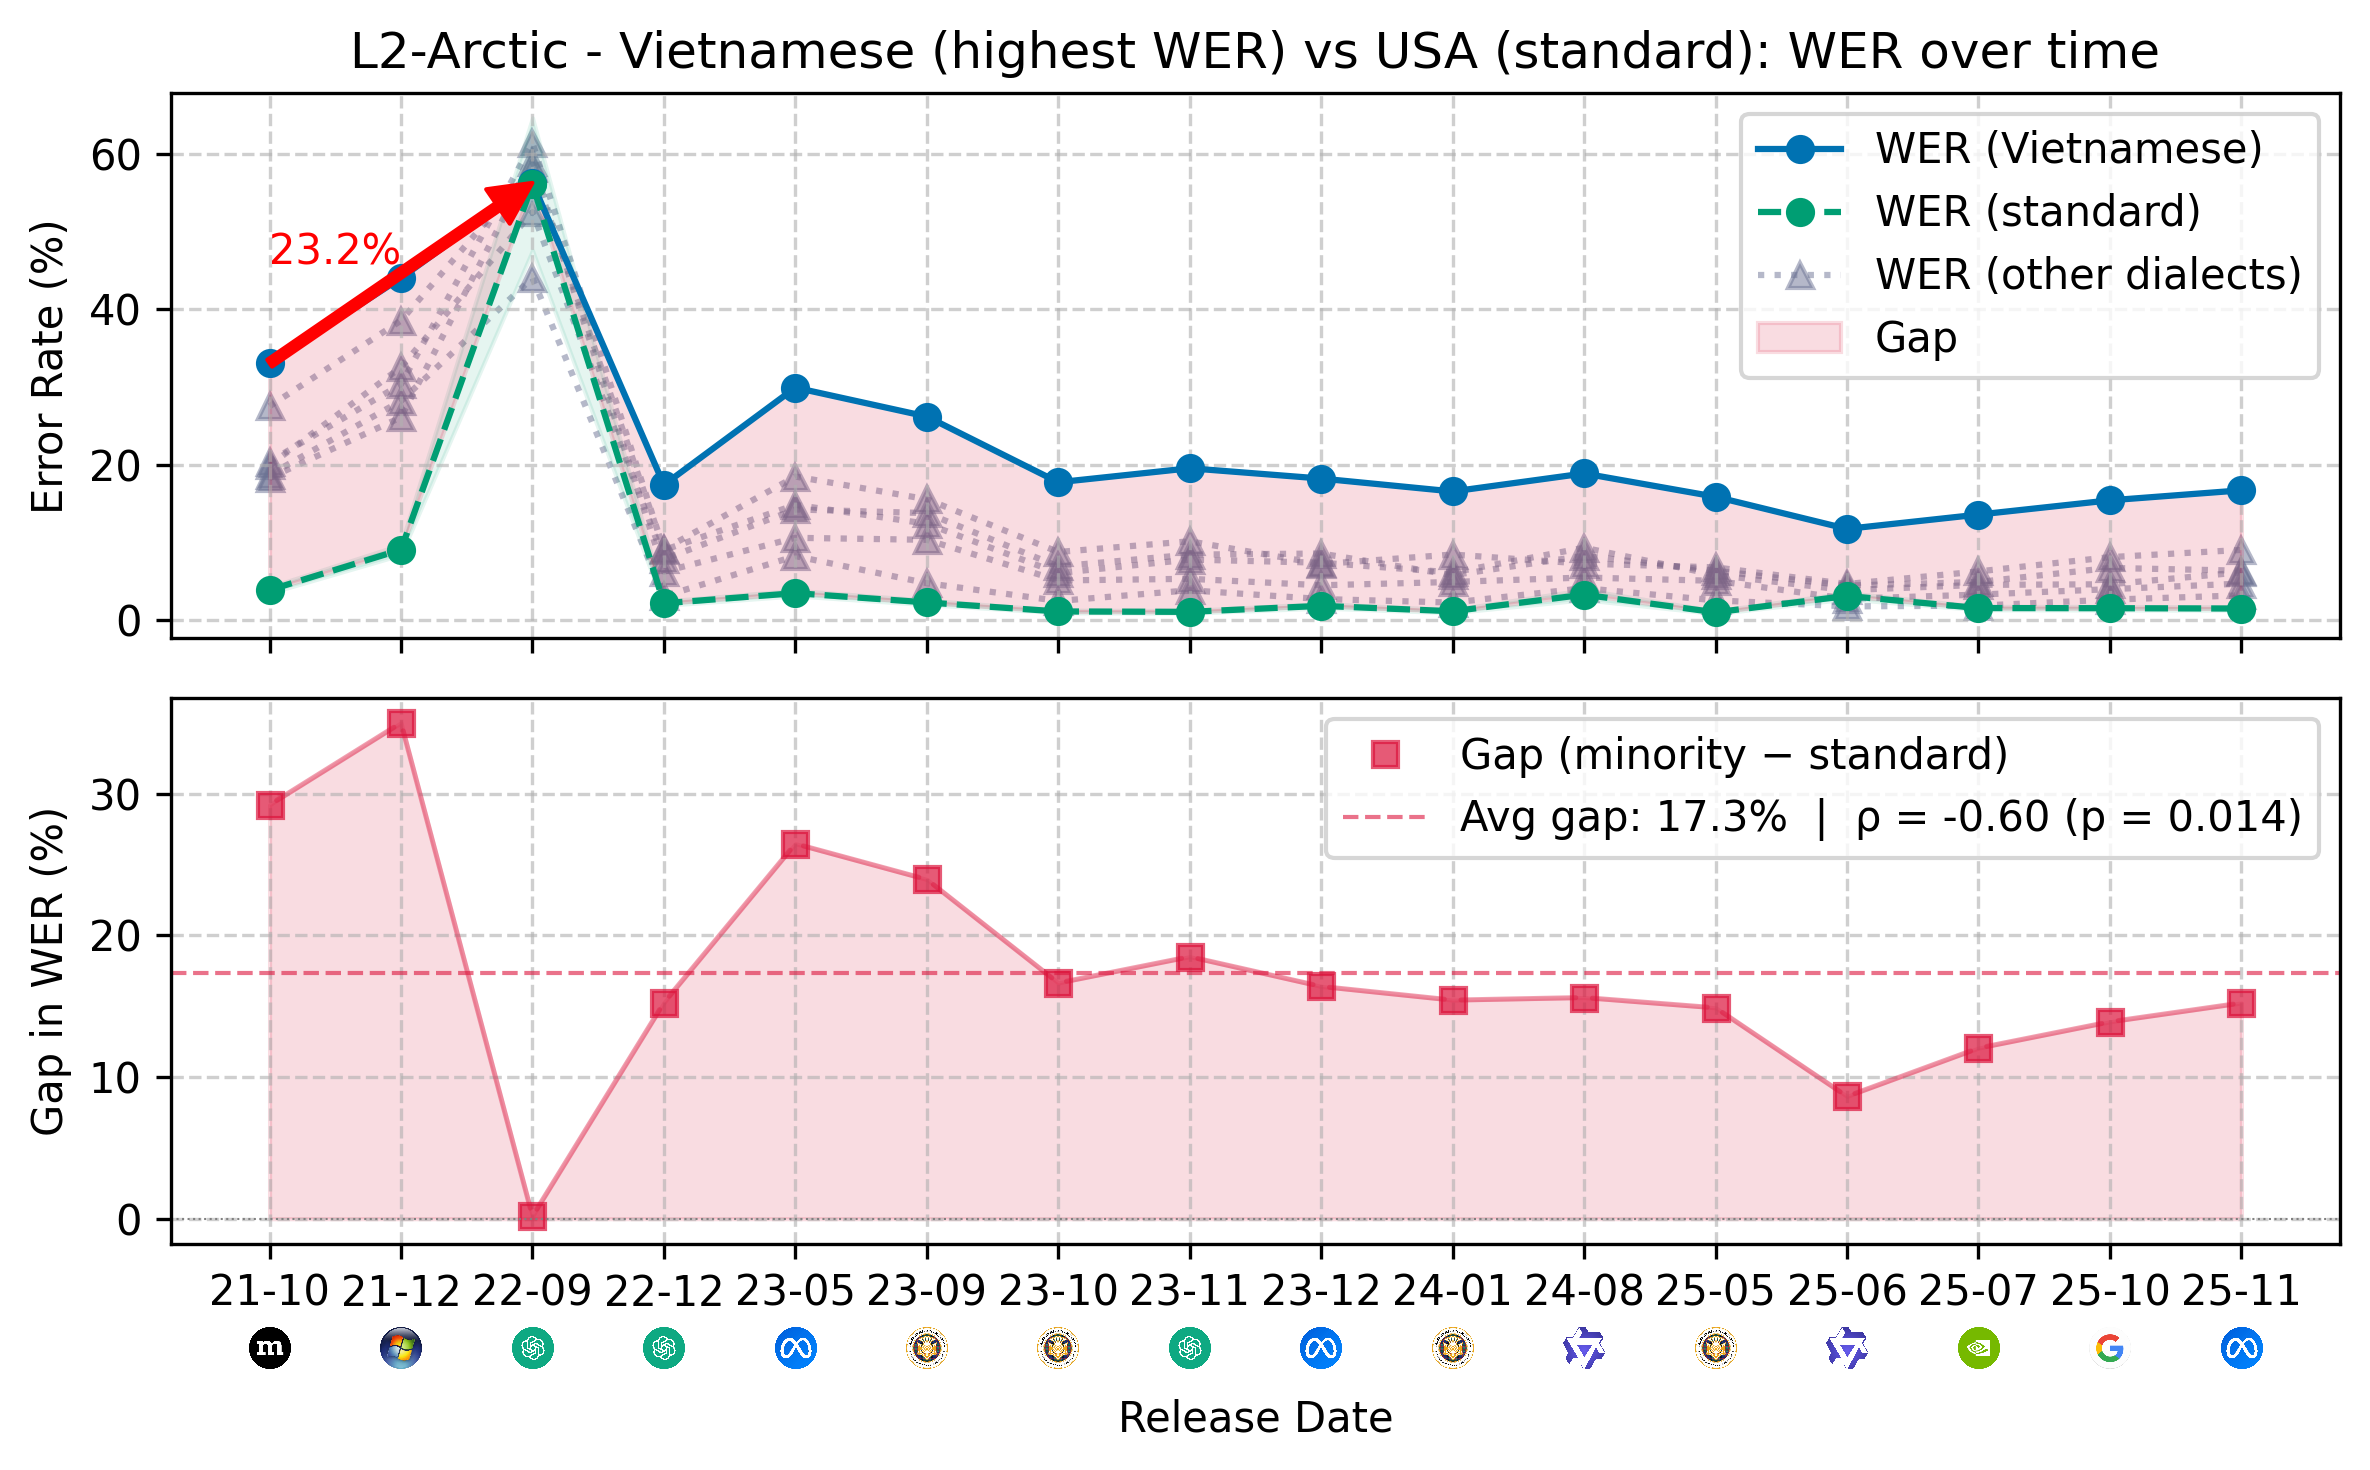


=== Dataset: L2-Arctic Spontaneous ===
  native_language  avg_regression  max_regression
0          Arabic        0.017825        0.425245
1         Chinese        0.008359        0.158929
2           Hindi        0.018057        0.287790
3          Korean        0.026960        0.281935
4         Spanish        0.010056        0.340842
5             USA        0.008137        0.470588
6      Vietnamese        0.010803        0.122172

Max regression (USA): 47.06%

Native regression (USA): 47.06%

Average max regression (all languages except USA): 26.95%

Average max regression (all languages): 29.82%


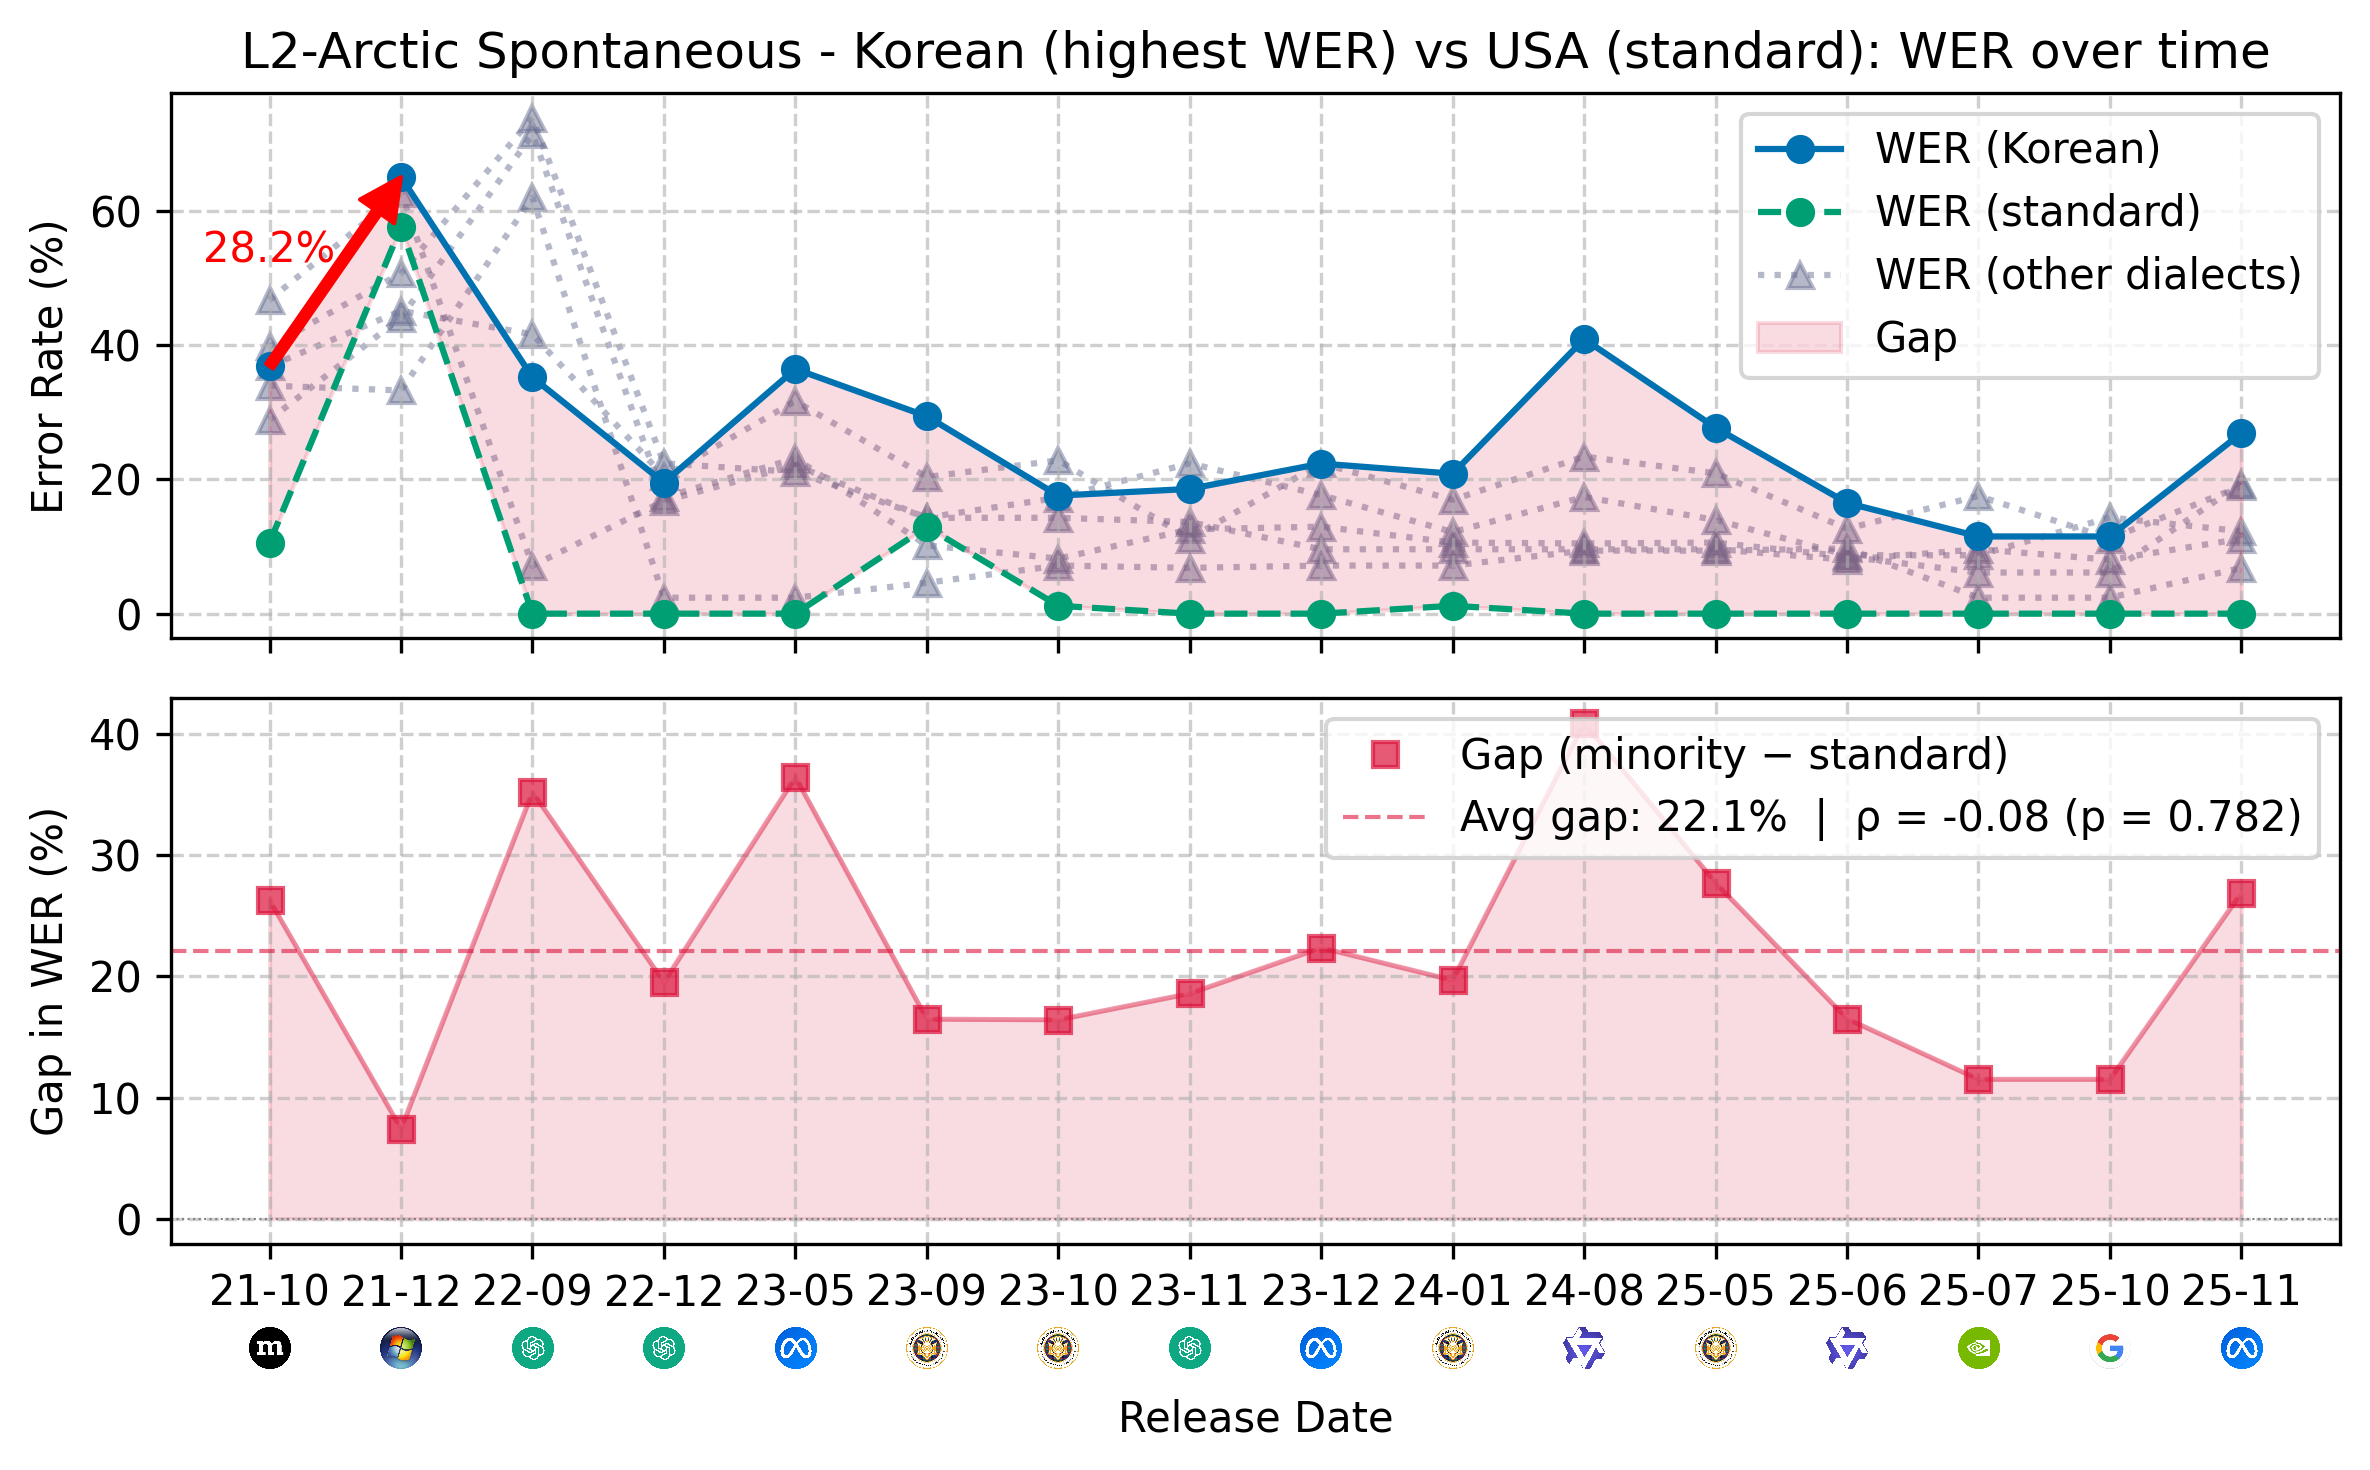


=== Dataset: Openslr83 ===
    native_language  avg_regression  max_regression
0     Irish English        0.010675        0.329163
1  Midlands English        0.004980        0.172484
2  Northern English        0.009462        0.174109
3  Scottish English        0.004311        0.099995
4  Southern English        0.004756        0.121009
5     Welsh English        0.004438        0.091499

Max regression (Irish English): 32.92%

Native regression (Southern English): 12.10%

Average max regression (all languages except Southern English): 17.35%

Average max regression (all languages): 16.47%


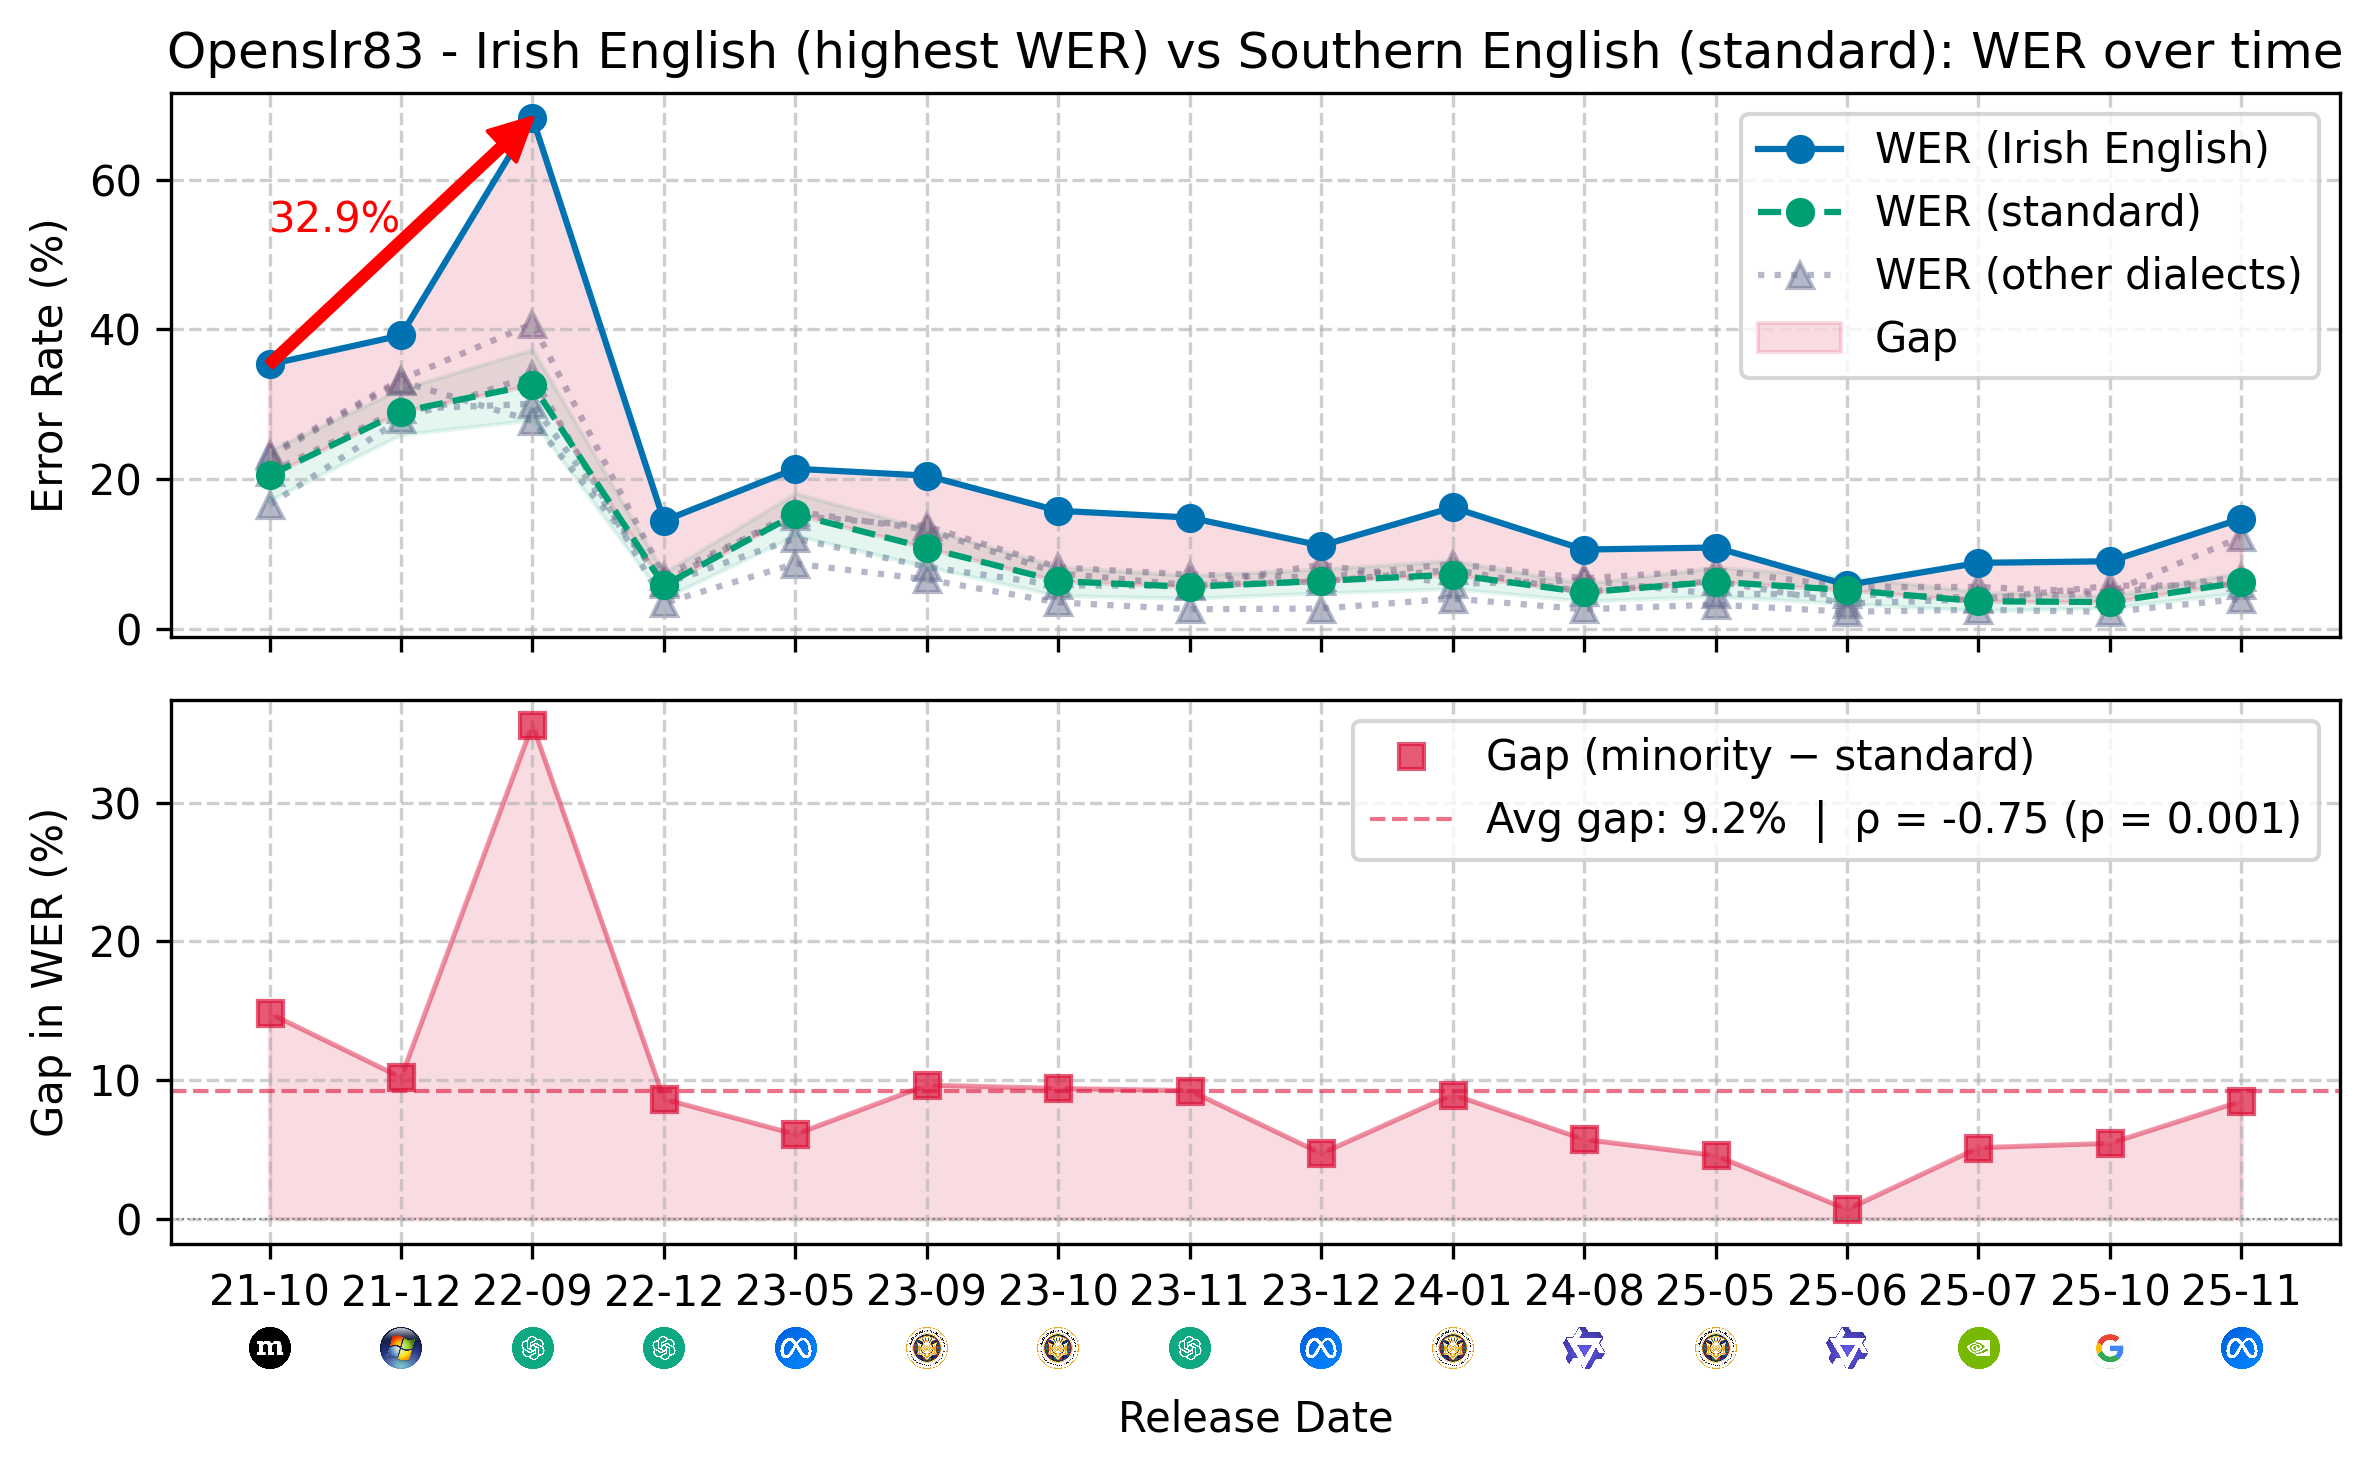


=== Dataset: SAA ===
  native_language  avg_regression  max_regression
0       Afrikaans        0.013244        0.385989
1        Albanian        0.008250        0.193183
2         Amazigh        0.017355        0.464286
3         Amharic        0.009484        0.139449
4          Arabic        0.005905        0.076247
5        Armenian        0.006962        0.142249
6          Bafang        0.092857        0.500000
7         Bambara        0.012567        0.229915
8            Bari        0.022642        0.274725
9          Basque        0.015705        0.192308

Max regression (Estonian): 60.99%

Native regression (English): 25.35%

Average max regression (all languages except English): 23.25%

Average max regression (all languages): 23.27%


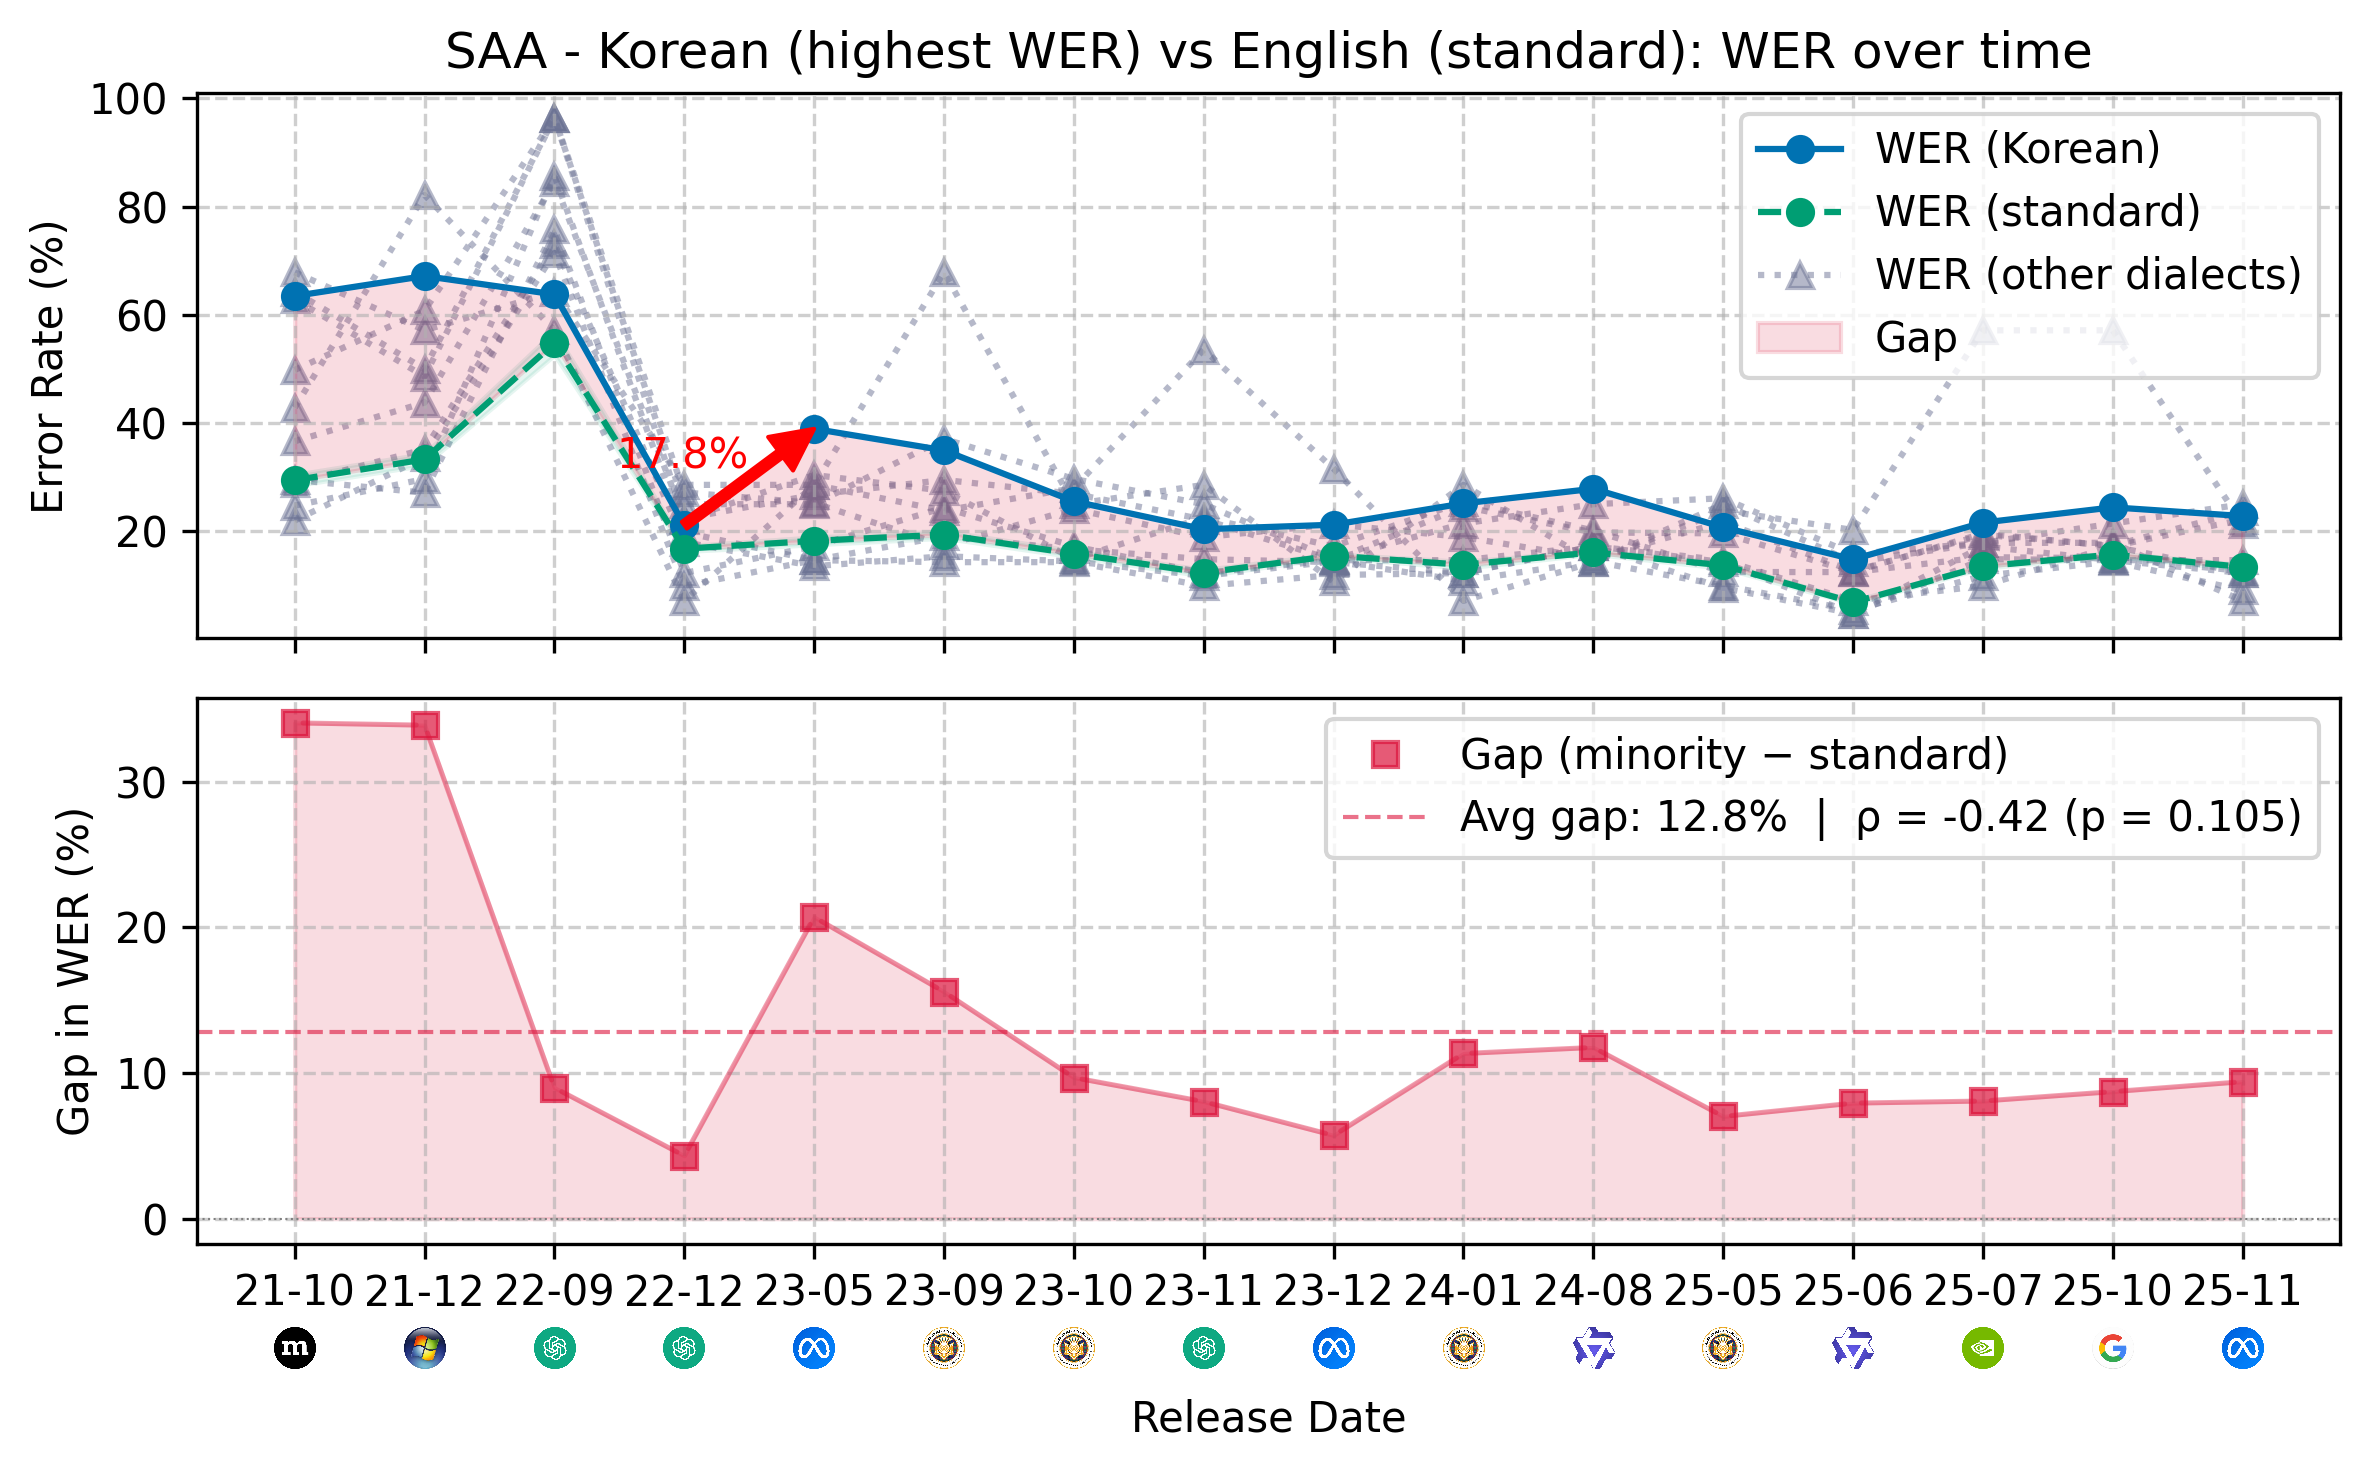

In [22]:
from sklearn.linear_model import HuberRegressor
from scipy.stats import spearmanr

WER_COLOR = colors[0]
WER_NATIVE_COLOR = colors[1]
CER_COLOR = colors[2]
CER_NATIVE_COLOR = colors[3]
UNCONDITIONAL_COLOR = colors[-1]
INCLUDE_CER = False
REQUIRE_NATIVE = True
# WORST_CRITERIA = 'max_regression'
# WORST_CRITERIA = 'avg_regression'
WORST_CRITERIA = 'highest_wer'
INCLUDE_UNCONDITIONAL = False
PLOT_TOP_TEN_DIALECTS = True
# STATISTIC = 'median'
STATISTIC = 'mean'
# ERROR_METRIC = 'std'
ERROR_METRIC = 'sem'
FALLBACK_L1_DATASET = {
    'L2-Arctic': 'L1-Arctic'
}
SHOW_MAX_REGRESSION_ARROW = True 

# optionally customize markers (e.g., with a flag) by providing a map from native-language to file path
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
IMAGES = {}
# add model logos to the x-axis
MODEL_LOGOS = {
    'Deepspeech': 'logos/mozilla.png',
    'WavLM Libri-100h': 'logos/microsoft.png',
    'Whisper Large v1': 'logos/openai.png',
    'Whisper Large v2': 'logos/openai.png',
    'MMS 1B All': 'logos/meta.png',
    'SeamlessM4T': 'logos/meta.png',
    'Whisper Large v3': 'logos/openai.png',
    'OWSM 1.0 272M': 'logos/cmu.png',
    'OWSM 2.0 739M': 'logos/cmu.png',
    'OWSM 3.1 1B': 'logos/cmu.png',
    'OWSM 4.0 1B': 'logos/cmu.png',
    'Qwen2 Audio 7B': 'logos/qwen.png',
    'Qwen3 ASR 1.7B': 'logos/qwen.png',
    'Qwen3 Audio 14B': 'logos/qwen.png',
    'Canary Qwen 2.5B': 'logos/nvidia.png',
    'Google Chirp 3': 'logos/google.png',
    'Omnilingual 7B': 'logos/meta.png',
}

for dataset, df_d in results.groupby('dataset'):      
    if dataset == 'L1-Arctic': # skip L1-Arctic since it's just a reference for native performance, not a focus of the analysis
        continue
    # outliers
    df_d = df_d[(df_d["cer"] <= 1) & (df_d["wer"] <= 1)] # drop outliers
    MIN_SAMPLES = 1 if 'L2-Arctic Spontaneous' in dataset else 2 # type: ignore ; ensure we have at least MIN_SAMPLES samples for a language to include it
    t = pd.DataFrame(df_d['native_language'].value_counts() / len(df_d['model'].unique()) >= MIN_SAMPLES).reset_index()
    t = t[t['count']]['native_language'].unique()
    df_d = df_d[df_d['native_language'].isin(t)]

    # Determine native language
    native_lang = set(df_d['native_language']).intersection(['USA', 'Southern English', 'English', 'ENG'])
    native_lang = native_lang.pop() if len(native_lang) > 0 else None
    if native_lang is None and dataset in FALLBACK_L1_DATASET:
        native_lang = 'USA'
        df_d = pd.concat([df_d, results[(results['dataset'] == FALLBACK_L1_DATASET[dataset]) & (results['native_language'] == native_lang)]]) # type: ignore

    df_d['release_date'] = df_d['release_date'].apply(lambda d: d[2:]) # truncate years
    
    # Compute regression (max diff of newer_model_wer - older_model_wer)
    regressions = []
    res = []
    max_pairs = {}
    for lang, df_lang in df_d.groupby('native_language'):
        df_lang_sorted = (
            df_lang.groupby(['model', 'release_date'])
            .agg({'wer': STATISTIC, 'cer': STATISTIC})
            .reset_index()
            .sort_values('release_date')
        )
        
        # Compute pairwise WER differences over time
        max_regression = avg_regression = 0.0
        max_pair = (None, None)
        count = 0
        for i in range(len(df_lang_sorted)):
            for j in range(i + 1, len(df_lang_sorted)):
                diff = df_lang_sorted.iloc[j]['wer'] - df_lang_sorted.iloc[i]['wer']
                if diff > max_regression:
                    max_regression = diff
                    # max_pair = (df_lang_sorted.iloc[i]['release_date'], df_lang_sorted.iloc[i]['release_date'])
                    max_pair = (i, j)
                avg_regression += diff if diff > 0 else 0
                count += 1
        avg_regression /= count
        max_pairs[lang] = max_pair
        
        res.append({
            'native_language': lang,
            'avg_regression': avg_regression,
            'max_regression': max_regression
        })
        regressions.append(max_regression)
    
    # Convert to DataFrame and print
    reg_df = pd.DataFrame(res)

    if WORST_CRITERIA == 'highest_wer':
        top_lang = None
        max_area = -1
        for l in reg_df['native_language'].unique():
            area = df_d[df_d['native_language'] == l].groupby(['release_date', 'model']).agg({'wer': STATISTIC}).sum()['wer']
            if area > max_area:
                top_lang = l
                max_area = area
    else:
        top_lang = reg_df.loc[reg_df[WORST_CRITERIA].idxmax(), 'native_language']
    if REQUIRE_NATIVE and not (native_lang and native_lang != top_lang):
        continue

    # if the dataset is SAA, use Korean as the top language
    if dataset == 'SAA' and 'Korean' in reg_df['native_language'].values:
        top_lang = 'Korean'

    # Print overall stats
    print(f"\n=== Dataset: {dataset} ===")
    print(reg_df.head(10))
    print(f"\nMax regression ({reg_df.loc[reg_df['max_regression'].idxmax(), 'native_language']}): {reg_df['max_regression'].max() * 100:.2f}%")
    if native_lang and native_lang != top_lang:
        print(f"\nNative regression ({native_lang}): {reg_df[reg_df['native_language'] == native_lang]['max_regression'].to_list()[0] * 100:.2f}%")
        print(f"\nAverage max regression (all languages except {native_lang}): {reg_df[reg_df['native_language'] != native_lang]['max_regression'].mean() * 100:.2f}%")
    print(f"\nAverage max regression (all languages): {reg_df['max_regression'].mean() * 100:.2f}%")
    
    # Plot WER and CER over time for that language
    df_plot = (
        df_d[df_d['native_language'] == top_lang]
        .groupby(['release_date', 'model'])
        .agg({'wer': [STATISTIC, ERROR_METRIC], 'cer': [STATISTIC, ERROR_METRIC]}) # type: ignore
        .reset_index()
    )
    df_plot.columns = ['release_date', 'model', 'wer_mean', 'wer_std', 'cer_mean', 'cer_std']
    df_plot = df_plot.sort_values('release_date')

    # Also plot the native dialect if present in the dataset
    if native_lang and native_lang != top_lang:
        df_native_plot = (
            df_d[df_d['native_language'] == native_lang]
            .groupby(['release_date', 'model'])
            .agg({'wer': [STATISTIC, ERROR_METRIC], 'cer': [STATISTIC, ERROR_METRIC]})
            .reset_index()
        )
        df_native_plot.columns = ['release_date', 'model', 'wer_mean', 'wer_std', 'cer_mean', 'cer_std']
        df_native_plot = df_native_plot.sort_values('release_date')
    else:
        df_native_plot = None
    
    # plt.figure(figsize=(8, 5))
    # fig, ax1 = plt.subplots(figsize=(8, 5))
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    # --- Top panel: individual WERs ---
    wer_line, = ax1.plot(df_plot['release_date'], df_plot['wer_mean'] * 100, '-o', color=WER_COLOR, label=f'WER ({top_lang})')
    # ax1.fill_between(
    #     df_plot['release_date'],
    #     (df_plot['wer_mean'] - df_plot['wer_std']) * 100,
    #     (df_plot['wer_mean'] + df_plot['wer_std']) * 100,
    #     color=wer_line.get_color(), alpha=0.2
    # )

    if df_native_plot is not None:
        wer_native_line, = ax1.plot(df_native_plot['release_date'], df_native_plot['wer_mean'] * 100, '--o',
             color=WER_NATIVE_COLOR, label='WER (standard)')
        ax1.fill_between(
            df_native_plot['release_date'],
            (df_native_plot['wer_mean'] - df_native_plot['wer_std']) * 100,
            (df_native_plot['wer_mean'] + df_native_plot['wer_std']) * 100,
            color=wer_native_line.get_color(), alpha=0.1
        )

    if PLOT_TOP_TEN_DIALECTS:
        top_languages = reg_df[(reg_df['native_language'] != native_lang) & (reg_df['native_language'] != top_lang)].sort_values('max_regression', ascending=False).head(10)['native_language']
        df_top = df_d[df_d['native_language'].isin(top_languages)].groupby(['native_language', 'release_date', 'model']).agg({'wer': [STATISTIC, ERROR_METRIC], 'cer': [STATISTIC, ERROR_METRIC]}).reset_index()
        df_top.columns = ['native_language', 'release_date', 'model', 'wer_mean', 'wer_std', 'cer_mean', 'cer_std']
        df_top = df_top.sort_values('release_date')
        for i, l in enumerate(top_languages):
            ax1.plot(df_top[df_top['native_language'] == l]['release_date'], df_top[df_top['native_language'] == l]['wer_mean'] * 100, ':^', color=UNCONDITIONAL_COLOR, alpha=0.5, label='WER (other dialects)' if i == 0 else None, zorder=-1)

    if SHOW_MAX_REGRESSION_ARROW:
        def offset_along_line(ax, x0, y0, x1, y1, pixel_offset):
            p0 = ax.transData.transform((x0, y0))
            p1 = ax.transData.transform((x1, y1))
            d = p1 - p0
            d = d / np.linalg.norm(d)
            p0n = p0 + pixel_offset * d
            p1n = p1 - pixel_offset * d
            x0n, y0n = ax.transData.inverted().transform(p0n)
            x1n, y1n = ax.transData.inverted().transform(p1n)
            return x0n, y0n, x1n, y1n

        release_date_locations = [i for i in range(len(df_plot))]
        max_pair = max_pairs[top_lang]
        start_x = release_date_locations[max_pair[0]]
        start_y = 100 * df_plot.iloc[max_pair[0]]['wer_mean']
        end_x = release_date_locations[max_pair[1]]
        end_y = 100 * df_plot.iloc[max_pair[1]]['wer_mean']
        pixel_offset = 15
        sx, sy, ex, ey = offset_along_line(ax1, start_x, start_y, end_x, end_y, pixel_offset)
        ax1.annotate("", xy=(ex, ey), xytext=(sx, sy), arrowprops=dict(headlength=10, headwidth=10, width=2, color='red'))
        mid_data = ((start_x + end_x) / 2, (start_y + end_y) / 2)
        mid_disp = ax1.transData.transform(mid_data)
        perp = np.array([-(end_y - start_y), end_x - start_x])
        perp = perp / np.linalg.norm(perp)
        label_disp = mid_disp + 8 * perp
        label_x, label_y = ax1.transData.inverted().transform(label_disp)
        ax1.text(label_x, label_y, f"{end_y - start_y:.1f}%", color="red", verticalalignment='bottom', horizontalalignment='right')

    ax1.set_ylabel("Error Rate (%)")
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.set_title(f"{dataset} - {top_lang} ({'worst regression' if WORST_CRITERIA != 'highest_wer' else 'highest WER'}) vs {native_lang} (standard): WER over time")

    ax1.fill_between(
        df_plot['release_date'],
        df_plot['wer_mean'] * 100,
        df_native_plot['wer_mean'] * 100,
        alpha=0.15, color='crimson', label='Gap'
    )
    ax1.legend()

    # --- Bottom panel: gap + regression line ---
    if df_native_plot is not None:
        merged = pd.merge(
            df_plot[['release_date', 'wer_mean']],
            df_native_plot[['release_date', 'wer_mean']],
            on='release_date',
            suffixes=('_minority', '_standard')
        )
        gap = (merged['wer_mean_minority'] - merged['wer_mean_standard']) * 100
        x = np.arange(len(gap))

        ax2.plot(merged['release_date'], gap, 's', color='crimson', alpha=0.7, label='Gap (minority − standard)')
        release_dates = merged['release_date']
        ax2.fill_between(release_dates, gap, 0,
                    where=gap > 0,
                    alpha=0.15, color='crimson')

        for i in range(len(gap) - 1):
            ax2.annotate("",
                xy=(i + 1, gap.iloc[i + 1]),
                xytext=(i, gap.iloc[i]),
                arrowprops=dict(
                    arrowstyle='-', 
                    color='crimson',
                    alpha=0.4,
                    lw=1.2
                )
            )

        # OLS trend line with R²
        m, b = np.polyfit(x, gap, 1)
        predicted = m * x + b
        ss_res = np.sum((gap - predicted) ** 2)
        ss_tot = np.sum((gap - np.mean(gap)) ** 2)
        r2 = 1 - ss_res / ss_tot

        rho, p_value = spearmanr(x, gap)
        avg_gap = np.mean(gap)
        # ax2.axhline(avg_gap, color='crimson', linewidth=1, linestyle='--', alpha=0.6, label=f'Avg gap: {avg_gap:.1f}%')
        ax2.axhline(avg_gap, color='crimson', linewidth=1, linestyle='--', alpha=0.6,
            label=f'Avg gap: {avg_gap:.1f}%  |  ρ = {rho:.2f} (p = {p_value:.3f})')
        # ax2.plot(merged['release_date'], predicted, '-', color='crimson',
        #  linewidth=1.5, alpha=0.5, label=f'Trend (ρ={rho:.2f})')
        # ax2.plot(merged['release_date'], predicted, '-', color='crimson',
        #         #  linewidth=1.5, alpha=0.5, label=f'Trend (R²={r2:.2f})')
        #          linewidth=1.5, alpha=0.5, label=f'Trend (r={r:.2f})')

        ax2.axhline(0, color='gray', linewidth=0.5, linestyle=':')
        ax2.set_ylabel("Gap in WER (%)")
        ax2.legend()
        ax2.grid(True, linestyle='--', alpha=0.6)

    if MODEL_LOGOS:
        for x_pos, model in zip(range(len(df_plot)), df_plot['model']):
            im = plt.imread(MODEL_LOGOS[model])
            img = OffsetImage(im, zoom=10 / im.shape[0])
            ab = AnnotationBbox(
                img, (x_pos, ax2.get_ylim()[0]),
                frameon=False, box_alignment=(0.5, 0.5),
                xybox=(0., -25.), boxcoords="offset points",
            )
            ax2.add_artist(ab)

    ax2.set_xlabel("Release Date", labelpad=20 if MODEL_LOGOS else None)
    plt.tight_layout()
    # plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
    save_dir = "aies_plots"
    os.makedirs(save_dir, exist_ok=True)

    img_filename = dataset_to_img_filename_mapping.get(dataset)
    if img_filename:
        plt.savefig(os.path.join(save_dir, img_filename))
    else:
        raise ValueError(f"No image filename mapping found for dataset {dataset}. Please add an entry to dataset_to_img_filename_mapping.")
    plt.show()
    # save the datasets under "post_rebuttal_plots"